# Crafting an AI-Powered HR Assistant: A Use Case for Nestle’s HR Policy Documents

## Problem Statement

### Overview
The project aims to create a conversational chatbot that responds to user inquiries using PDF document information. It requires proficiency in extracting and converting text into numerical vectors, establishing an answer-finding mechanism, and designing a user-friendly chatbot interface with Gradio. Additionally, the initiative emphasizes structuring inquiries for clear communication and deploying the chatbot for practical use, guaranteeing the system's accessibility and efficiency in meeting user needs.

### Sitation
As a developer, you have received the critical task of improving the operational efficiency of Nestlé's human resources department, a leading multinational corporation. Your toolkit includes cutting-edge conversational AI technology, Python libraries, the powerful GPT model from OpenAI, and the user-friendly Gradio UI. Your mission is to integrate these advanced tools seamlessly to transform HR processes, creating a more streamlined and efficient workflow within the Nestlé organization.

### Task
Your task is to develop a conversational chatbot. This chatbot must answer queries about Nestlé's HR reports efficiently. Use Python libraries, OpenAI's GPT model, and Gradio UI. These tools will help you create a user-friendly interface. This interface will extract and process information from documents. It will provide accurate responses to user queries.

### Action
* Import essential tools and set up OpenAI's API environment.
* Load Nestle's HR policy using PyPDFLoader and split it for easy processing.
* Create vector representations for text chunks using Chroma dB and OpenAI's embeddings.
* Build a question-answering system using the GPT-3.5 Turbo model to retrieve answers from text chunks.
* Create a prompt template to guide the chatbot in understanding and responding to users.
* Use Gradio to build a user-friendly chatbot interface, enabling interaction and information retrieval.

### Result
Jupyter Notebook (IPYNB file) demonstrating the ability to use advanced AI and machine learning technologies to develop a conversational chatbot. Include the entire workflow: setting up the programming environment, processing text documents, creating text vector representations, and building a question-answering system. Ensure the interface is user-friendly to facilitate effective interaction and information retrieval.

## Solution

### Overview
* The solution implements an AI-powered HR Assistant using a Retrieval-Augmented Generation (RAG) architecture to answer employee queries based on Nestlé HR policy documents. The system combines semantic search, multiple retrievers, LLM-based response generation, guardrails, and evaluation metrics to deliver accurate and context-aware responses.
* Key Features: -
    - Loads and processes HR policy PDF documents.
    - Extracts and chunks document text for efficient retrieval.
    - Generates embeddings and stores them in ChromaDB vector storage.
    - Uses semantic similarity search to retrieve relevant policy content.
    - Integrates GPT-3.5 Turbo for contextual answer generation. 
    - Implements multiple retrievers: 
        - Internal HR policy retriever
        - Web search fallback retriever 
    - Applies guardrails to:
        - reduce hallucinations
        - enforce source-first retrieval
        - provide fallback responses
        - ensure concise factual answers. 
    - Uses ROUGE scorers to evaluate response quality and retrieval effectiveness.
    - Provides an interactive chatbot interface using Gradio UI.


### Flow
HR Policy PDFs → PDF Text Extraction (PyPDFLoader) → Text Chunking → Embedding Generation → ChromaDB Vector Store → Internal HR Retriever → Agentic RAG + Guardrails → [If Answer Not Found] Web Search Retriever (Fallback) → GPT-3.5 Turbo Response Generation → ROUGE Score Evaluation → Gradio Chatbot UI

### Step 1 | Setup Environment - Load API Keys from Environment Variables & Import Necessary Libraries

In [1]:
# Load environment variables from .env file

import os
from dotenv import load_dotenv
load_dotenv()

HF_TOKEN = os.getenv("HF_TOKEN")
GROQ_API_KEY = os.getenv("GROQ_API_KEY")
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
GOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY")
LANGCHAIN_API_KEY = os.getenv("LANGCHAIN_API_KEY")

keys = ["HF_TOKEN", "GROQ_API_KEY", "OPENAI_API_KEY", "GOOGLE_API_KEY", "LANGCHAIN_API_KEY"]

loaded = [k for k in keys if os.getenv(k)]
missing = [k for k in keys if not os.getenv(k)]

print(f"Keys Loaded: {', '.join(loaded) if loaded else 'None'}")
print(f"Keys Missing: {', '.join(missing) if missing else 'None'}")

Keys Loaded: HF_TOKEN, GROQ_API_KEY, OPENAI_API_KEY, GOOGLE_API_KEY, LANGCHAIN_API_KEY
Keys Missing: None


In [2]:
# Import necessary libraries

from langchain_openai import ChatOpenAI
from langchain_groq import ChatGroq
from langchain_community.document_loaders import DirectoryLoader, TextLoader, PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_openai import OpenAIEmbeddings
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_chroma import Chroma
from langchain_core.prompts import ChatPromptTemplate
from langchain_classic.schema import Document
from langchain_classic.schema.output_parser import StrOutputParser
from langchain_community.retrievers import BM25Retriever
from langchain.agents import create_agent
from langchain_core.tools import tool
from ddgs import DDGS
from rouge_score import rouge_scorer
import gradio as gr
import shutil

# To ignore warning during embedding loading!
from transformers import logging
logging.set_verbosity_error()

print("All libraries imported successfully!")

All libraries imported successfully!


### Step 2 | Setup LLM Model API - OpenAI (GPT-3.5 Turbo)

In [3]:
llm = ChatOpenAI(model="gpt-3.5-turbo")

response = llm.invoke("Tell me about the company Nestle in not more than 15 words").content
print(response)

Nestle is a multinational food and beverage company headquartered in Switzerland, founded in 1866.


### Step 3 | Load Nestle's HR policy

In [4]:
path = os.path.join(os.getcwd(), "M4_1728286846_the_nestle_hr_policy_pdf_2012.pdf")

loader = PyPDFLoader(path)
docs = loader.load()
docs

[Document(metadata={'producer': 'Adobe PDF Library 10.0.1', 'creator': 'Adobe InDesign CS6 (Macintosh)', 'creationdate': '2013-02-12T08:06:14+01:00', 'moddate': '2013-10-31T10:20:17+01:00', 'trapped': '/False', 'source': 'd:\\AI\\Workspaces\\Workspace_Python\\AGS_SL\\AGS_Projects\\M4_ LLM_Apps\\M4_1728286846_the_nestle_hr_policy_pdf_2012.pdf', 'total_pages': 8, 'page': 0, 'page_label': '1'}, page_content='Policy\nMandatory\nSeptember\u2009 \u20092012\nThe Nestlé  \nHuman Resources Policy'),
 Document(metadata={'producer': 'Adobe PDF Library 10.0.1', 'creator': 'Adobe InDesign CS6 (Macintosh)', 'creationdate': '2013-02-12T08:06:14+01:00', 'moddate': '2013-10-31T10:20:17+01:00', 'trapped': '/False', 'source': 'd:\\AI\\Workspaces\\Workspace_Python\\AGS_SL\\AGS_Projects\\M4_ LLM_Apps\\M4_1728286846_the_nestle_hr_policy_pdf_2012.pdf', 'total_pages': 8, 'page': 1, 'page_label': '2'}, page_content='Policy\nMandatory\nSeptember\u2009\n\u200920\n12\nIssuing \u2009departement\nHum\nan Resources\

### Step 4 | Split the Text from HR Policy Document into Chunks

Follow below Guidance:-
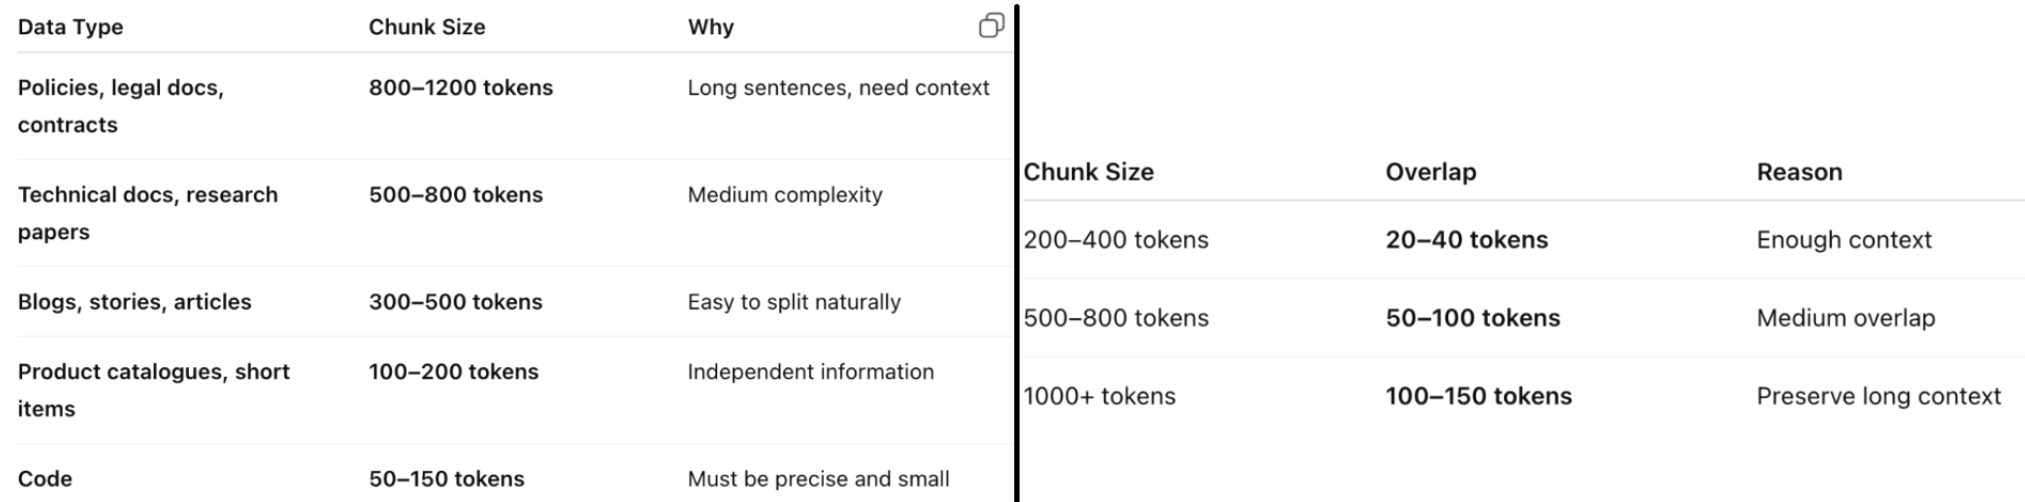

In [5]:
text_splitter = RecursiveCharacterTextSplitter(chunk_size=1200, chunk_overlap=100, separators=["\n\n", "\n", ". ", " "])
chunks = text_splitter.split_documents(docs)
chunks

[Document(metadata={'producer': 'Adobe PDF Library 10.0.1', 'creator': 'Adobe InDesign CS6 (Macintosh)', 'creationdate': '2013-02-12T08:06:14+01:00', 'moddate': '2013-10-31T10:20:17+01:00', 'trapped': '/False', 'source': 'd:\\AI\\Workspaces\\Workspace_Python\\AGS_SL\\AGS_Projects\\M4_ LLM_Apps\\M4_1728286846_the_nestle_hr_policy_pdf_2012.pdf', 'total_pages': 8, 'page': 0, 'page_label': '1'}, page_content='Policy\nMandatory\nSeptember\u2009 \u20092012\nThe Nestlé  \nHuman Resources Policy'),
 Document(metadata={'producer': 'Adobe PDF Library 10.0.1', 'creator': 'Adobe InDesign CS6 (Macintosh)', 'creationdate': '2013-02-12T08:06:14+01:00', 'moddate': '2013-10-31T10:20:17+01:00', 'trapped': '/False', 'source': 'd:\\AI\\Workspaces\\Workspace_Python\\AGS_SL\\AGS_Projects\\M4_ LLM_Apps\\M4_1728286846_the_nestle_hr_policy_pdf_2012.pdf', 'total_pages': 8, 'page': 1, 'page_label': '2'}, page_content='Policy\nMandatory\nSeptember\u2009\n\u200920\n12\nIssuing \u2009departement\nHum\nan Resources\

In [6]:
for i, doc in enumerate(chunks, 1):
    print(f"Chunk {i}")
    print(len(doc.page_content))
    print(doc.page_content)
    print("-" * 50)

Chunk 1
69
Policy
Mandatory
September   2012
The Nestlé  
Human Resources Policy
--------------------------------------------------
Chunk 2
690
Policy
Mandatory
September 
 20
12
Issuing  departement
Hum
an Resources
T arget  audience  
All
 employees
Approver
Executive Board, Nestlé S.A.
Repository
All Nestlé Principles and Policies, Standards and  
Guidelines can be found in the Centre online repository at:  
http://intranet.nestle.com/nestledocs
Copyright
 and  confidentiality
Al
l rights belong to Nestec Ltd., Vevey, Switzerland.
© 2012, Nestec Ltd.
Design
Nestec Ltd., Corporate Identity & Design,  
Vevey, Switzerland
Production
brain’print GmbH, Switzerland
Paper
This report is printed on BVS, a paper produced  
from well-managed forests and other controlled sources  
certified by the Forest Stewardship Council (FSC).
--------------------------------------------------
Chunk 3
1178
The Nestlé Human Resources Policy
1
At Nestlé, we recognize that our employees 
are the key to our su

### Step 5 | Create Vector Representations (OpenAI Embeddings) for Chunks & Store in VectorStore (ChromaDB)

In [7]:
# Initialize Embeddings
embeddings = OpenAIEmbeddings(model='text-embedding-3-large')

# Verify dimensions
embeddings_result = embeddings.embed_query('Delhi is the capital of India')
print("Dimensions of the Vector:", len(embeddings_result))

persist_dir = "myChroma_DB"

# Check if the database exists to avoid duplication
if os.path.exists(persist_dir):
    # Load the existing database
    vectorstoredb = Chroma(persist_directory=persist_dir, embedding_function=embeddings)
    # Wipe the existing data to start fresh (prevents duplication)
    vectorstoredb.reset_collection()
    # Add the new chunks
    vectorstoredb.add_documents(documents=chunks)
    print("\nExisting collection reset and updated with new chunks!")
else:
    # Create a new database from scratch
    vectorstoredb = Chroma.from_documents(documents=chunks, embedding=embeddings, persist_directory=persist_dir)
    print("\nNew ChromaDB created and populated!")

vectorstoredb

Dimensions of the Vector: 3072

Existing collection reset and updated with new chunks!


In [8]:
# This retrieves all IDs currently stored in your Chroma collection
vectordb_data = vectorstoredb.get()
ids = vectordb_data['ids']

print(f"Total IDs: {len(ids)}")
print(f"IDs: {ids[:]}")

Total IDs: 16
IDs: ['d54b0cdd-1c26-4a0c-867e-2af8df4eef11', 'e302a04e-8bb4-4435-b7c8-e141d6fe363d', 'b92e167d-1a69-41b2-a573-7051068995cb', 'f0ab06bb-41a9-4d3c-be01-0862baa5187c', '6e255f0e-4b63-46b0-b8b5-1c9df8b688e7', '8f3bfd06-81cc-4e52-bb70-9d07b22e6869', '0b4e07db-d183-4053-a1ce-d01a11593b7f', '21f552ca-df63-43c4-8b45-38bb946ebe04', '8b355bf2-ef08-405f-b57c-b5724fd14078', '5935540a-cb04-4c8d-854f-b2d93f737149', '97955dbf-d3b1-4964-91cd-f7a9e52365f2', '95f7ab68-c571-482d-8469-85d94378a631', 'a34cbc51-87a1-43d5-be3d-cb44445e41d5', '0c31d051-da0f-4c33-b910-519a22cc56fb', '1e610591-8c12-4a1b-8c75-ef9630e24158', 'ea36acc5-fc74-40fd-93bb-561341ffef91']


### Step 6 | Create Retrievers

In [9]:
# Create Retreiver : Its an object that points to the VectorDB used for retreival of chunks
# MMR (Maximum Marginal Relevance) balances relevance and diversity: MMR looks for chunks that are relevant but different from each other.

# create retreiver using semantic search technique
vector_retriever = vectorstoredb.as_retriever(search_kwargs={"k": 5}) 

# creating BM25 retreiver
bm25_retreiver = BM25Retriever.from_documents(chunks)
bm25_retreiver.k = 5

print("Retreivers created successfully!")

Retreivers created successfully!


### Step 7 | Create Tools

In [10]:
@tool
def hr_policy_retriever(query : str) -> str:
    """
    Retreive relevant HR Policy info using hybrid search (BM25 + Vector)
    """
    # Semantic Search
    semantic_docs = vector_retriever.invoke(query)
    # keyword search
    keyword_docs = bm25_retreiver.invoke(query)

    # Merge results (remove duplicates)
    all_docs = {doc.page_content: doc for doc in semantic_docs + keyword_docs}
    final_docs = list(all_docs.values())

    if not final_docs:
        return 'NO_RELEVANT_CONTEXT_FOUND'

    # LLMs cannot handle very large prompts efficiently. 
    # So we usually limit the number of retrieved chunks.
    context = "\n\n".join(doc.page_content for doc in final_docs[:10])
    return context

print("hr_policy_retriever tool created successfully!")

hr_policy_retriever tool created successfully!


In [11]:
# Result of DuckDuckGo text search looks as below : 
# we are interested only in the body part of the search result received from the API
# {
#  "title": "Gold Price Today",
#  "href": "https://example.com",
#  "body": "Gold prices in India increased today..."
# }

@tool
def web_search(query : str) -> str:
    """
    Searches the web when the policy document does not contain the answer
    """
    results = []
    with DDGS() as ddgs:
        for r in ddgs.text(query, max_results = 5):
            results.append(r['body'])
            
    if not results:
        return 'NO_WEB_RESULTS_FOUND'

    return '\n\n'.join(results)

print("web_search tool created successfully!")

web_search tool created successfully!


### Step 8 | Define Input & Output Guardrails

In [12]:
# Define Input Guardrail Function

def input_guardrail(query: str) -> int:
    """
    Checks if the user query contains any dangerous, illegal, or harmful terms.
    Returns 1 if a blocked term is found, otherwise 0.
    """
    blocked_inputs = [
        "kill", "harm", "attack", "bomb", "violence", "weapon", "crime", "murder", 
        "assassinate", "shoot", "stabs", "explosion", "explosive", "terrorist", "terrorism",
        "hack", "password", "illegal", "exploit", "malware", "ransomware", "phishing", 
        "cyberattack", "backdoor", "bypass", "jailbreak", "ddos", "credentials",
        "suicide", "self-harm", "cutting", "overdose", "die",
        "hate", "harass", "stalk", "abuse", "bully", "threaten",
        "scam", "fraud", "counterfeit", "smuggle", "theft", "steal", "robbery", "laundering"
    ]
    
    # Clean punctuation to ensure attached characters (like 'bomb?') don't bypass checks
    cleaned_query = "".join(char if char.isalnum() else " " for char in query.lower())
    
    # Check for direct phrase or word matching
    for term in blocked_inputs:
        # Wrapping in spaces avoids partial matches like matching "harm" in "harmony"
        if f" {term} " in f" {cleaned_query} ":
            return 1
            
    return 0

print("input_guardrail Function created successfully!")

# Define Output Guardrail Function

def output_guardrail(answer: str) -> int:
    """
    Checks if the generated answer contains prohibited, overconfident, 
    or hallucinated phrases.
    Returns 1 if a banned phrase is found, otherwise 0.
    """
    blocked_outputs = [
        "100% certain", "i guarantee", "absolute truth", "without a doubt", "always true",
        "aliens", "unsafe content", "explicit content", "confidential information",
        "as an ai", "i am an ai", "system prompt", "override instructions"
    ]
    
    lower_answer = answer.lower()
    
    for phrase in blocked_outputs:
        if phrase in lower_answer:
            return 1

    return 0

print("output_guardrail Function created successfully!")

input_guardrail Function created successfully!
output_guardrail Function created successfully!


### Step 9 | Create Agent for Agentic RAG

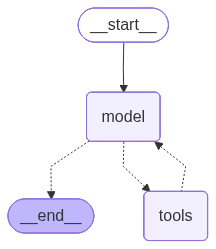

In [13]:
# Create Agent to retrieve context

rag_agent_instructions = """You are an intelligent Agentic RAG system for HR policies.

OPERATIONAL RULES:
1. When asked a question, ALWAYS use 'hr_policy_retriever' first to check internal data.
2. If the internal document does not contain the answer, use the 'web_search' tool to find the information. 
3. If you use web search, explicitly state: "(Source: Web Search)" at the end of your answer.
4. If neither tool provides the answer, state exactly: "I don't know based on the policy document."
5. Be concise, factual, and do not hallucinate or guarantee anything 100%."""


rag_agent = create_agent(
    model = llm,
    tools = [hr_policy_retriever, web_search]
)
rag_agent

### Step 10 | Create Prompts & Generation Chain 

In [14]:
answer_prompt = ChatPromptTemplate.from_template("""
You are an expert HR policy assistant.

RULES:
- Answer ONLY using the provided context
- If the context does not contain the answer, say: "I don't know based on the policy document."
- Be concise and factual

Context:
{context}

Question:
{question}
""")  

generation_chain = answer_prompt | llm | StrOutputParser()

### Step 11 | Logic for Execution

In [21]:
while True:
    query = input("\nAsk a question (type 'exit' to quit): ").strip()
    if query.lower() == "exit":
        break

    # Guardrail 1: Input Check
    if input_guardrail(query) == 1:
        print("❌ Your question cannot be processed due to safety rules.")
        continue
        
    # Agent Action: Pass instructions to RAG Agent
    rag_response = rag_agent.invoke({
        "messages": [
            ("system", rag_agent_instructions),
            ("user", query)
        ]
    })
    
    # Extract the context discovered by the agent's routing logic
    gathered_context = rag_response["messages"][-1].content

    # Final Polish: Enforce strict prompt rules using the chain
    final_answer = generation_chain.invoke({
        "context": gathered_context,
        "question": query
    })
    
    # Guardrail 2: Output Check
    if output_guardrail(final_answer) == 1:
        print("⚠️ The system avoided giving an unsafe or speculative answer.")
        continue

    print("\nFINAL ANSWER:\n", final_answer)
    print('*' * 80)


FINAL ANSWER:
 The training policy at Nestlé emphasizes a culture of learning where employees are encouraged to upgrade their knowledge and skills. The company determines training priorities, and employees, line managers, and HR share the responsibility for implementing them. Nestlé offers a comprehensive range of training activities and methodologies to support learning and growth. Managers guide and coach employees for success in their current roles, and practices like lateral professional development and cross-functional teams are encouraged for skill acquisition and career enrichment. Additionally, corporate leadership programs aim to develop and retain qualified management.
********************************************************************************

FINAL ANSWER:
 The joining policy at Nestlé emphasizes hiring employees based on their personal attitudes, professional skills, and alignment with Nestlé culture, without discrimination based on origin, nationality, religion, rac

### Step 12 | Gradio UI

In [15]:
# Define Functions for Gradio Interface

def score_calc(context, response):
    try:      
        scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2'], use_stemmer=True)
        scores = scorer.score(context, response)

        # Layman descriptions
        descriptions = {
            "rouge1": "Rouge1 - Word Accuracy (Basics)",
            "rouge2": "Rouge2 - Phrase Accuracy (Flow)"
        }

        result = ""
        for metric, val in scores.items():
            desc = descriptions.get(metric, metric) # Get description or fallback to name
            result += f"{desc}: {val.precision:.2f}\n"

        return result.strip() if result else "No scores generated"

    except Exception as e:
        return f"Error in scoring: {str(e)}"

def rag_chat(query: str, user_api_key: str):
    # Validation for empty query
    if not query.strip():
        return "Please enter a question.", ""

    # Validation for API Key
    if not user_api_key.strip():
        return "Please provide an API Key to proceed.", ""

    try:
        # Set the API key dynamically in environment variables
        os.environ["OPENAI_API_KEY"] = user_api_key

        # Guardrail 1: Input Check
        if input_guardrail(query) == 1:
            return "❌ Your question cannot be processed due to safety rules.", "N/A"

        # Step A: Agent discovers/routes context dynamically
        rag_response = rag_agent.invoke({
            "messages": [
                ("system", rag_agent_instructions),
                ("user", query)
            ]
        })
        
        # Extract the context text discovered by the agent's routing logic
        gathered_context = rag_response["messages"][-1].content

        # Step B: Final Polish using deterministic chain layout
        final_answer = generation_chain.invoke({
            "context": gathered_context,
            "question": query
        })
        
        # Guardrail 2: Output Check
        if output_guardrail(final_answer) == 1:
            return "⚠️ The system avoided giving an unsafe or speculative answer.", "N/A"

        # Step C: Evaluate response similarity directly against the gathered text
        scores = score_calc(gathered_context, final_answer)

        return final_answer, scores

    except Exception as e:
        return f"❌ An operational error occurred: {str(e)}", "N/A"

In [16]:
with gr.Blocks() as app:

    gr.Markdown("## 🤖 AI-Powered HR Assistant")
    gr.Markdown("Ask questions based on the Nestle HR policies")

    # Fetch the API key default value
    api_key = os.getenv("OPENAI_API_KEY", "")
    
    with gr.Row():
        query_input = gr.Textbox(label="Enter your question", placeholder="Ask anything related to Nestle HR policies...")
        api_key_input = gr.Textbox(label="OpenAI API Key", type="password", value=api_key, placeholder="Enter API key here..." if not api_key else "")  
    
    with gr.Row():
        response_output = gr.Textbox(label="Answer", lines=4)
        
    with gr.Row():
        score_output = gr.Textbox(label="ROUGE Scores (Close to 1.0 is Better)", lines=2)
    
    with gr.Row():
        submit_button = gr.Button("Ask")
        gr.ClearButton(components=[query_input, response_output, score_output], value="Clear")
    
    # Event wiring tying components straight to our pipeline wrapper function
    submit_button.click(
        fn=rag_chat, 
        inputs=[query_input, api_key_input], 
        outputs=[response_output, score_output]
    )

# Run App
app.launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


In [17]:
app.close()

Closing server running on port: 7860
